## DnCNN Image Denoising Inference

This notebook implements image denoising using a pretrained DnCNN model on grayscale images.

### Import dependencies

In [52]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Verify dataset paths

In [53]:
import os
print("Degraded samples:", os.listdir("../data/degraded"))
print("Clean samples:", os.listdir("../data/clean"))

Degraded samples: ['image_6.png', 'image_0.png', 'image_2.png', 'image_4.png', 'image_8.png']
Clean samples: ['image_6.png', 'image_0.png', 'image_2.png', 'image_4.png', 'image_8.png']


### Define DnCNN model architecture

In [54]:
class DnCNN(nn.Module):
    def __init__(self, channels=3, num_of_layers=17, features=64):
        super(DnCNN, self).__init__()

        layers = []
        layers.append(nn.Conv2d(channels, features, 3, padding=1, bias=False))
        layers.append(nn.ReLU(inplace=True))

        for _ in range(num_of_layers - 2):
            layers.append(nn.Conv2d(features, features, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(features))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Conv2d(features, channels, 3, padding=1, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.dncnn(x)
        return x - noise

### Initialize grayscale DnCNN model

In [55]:
model = DnCNN(channels=1, num_of_layers=17)
model.eval()

print("Grayscale DnCNN model initialized")

Grayscale DnCNN model initialized


### Load pretrained weights

- Pretrained weights source: [cszn/KAIR](https://github.com/cszn/KAIR/tree/master/model_zoo)
- To download the pretrained weights, create a `/model/weights` directory and run this command in the terminal: `wget -O model/weights/dncnn_25.pth https://github.com/cszn/KAIR/raw/master/model_zoo/dncnn_25.pth`

In [56]:
weights_path = "../model/weights/dncnn_25.pth"

state_dict = torch.load(weights_path, map_location="cpu")

if "params" in state_dict:
    state_dict = state_dict["params"]

model.load_state_dict(state_dict, strict=False)
model.eval()

print("Weights are loaded successfully.")

Weights are loaded successfully.


### Select test image

In [57]:
filename = os.listdir("../data/degraded")[0]

degraded_path = os.path.join("../data/degraded", filename)
clean_path = os.path.join("../data/clean", filename)

print("Testing:", filename)

Testing: image_6.png


### Load grayscale images

In [58]:
degraded = cv2.imread(degraded_path, cv2.IMREAD_GRAYSCALE)
clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

print("Degraded shape:", degraded.shape)
print("Clean shape:", clean.shape)

Degraded shape: (1200, 1608)
Clean shape: (1200, 1608)


### Visualize degraded image

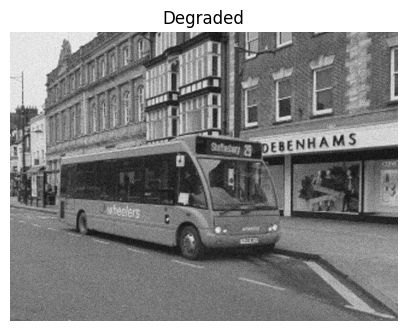

In [59]:
plt.figure(figsize=(5,5))
plt.title("Degraded")
plt.imshow(degraded, cmap="gray")
plt.axis("off")
plt.show()

### Preprocess image for model

In [60]:
img = degraded.astype(np.float32) / 255.0
img = np.expand_dims(img, axis=0)   # H,W -> 1,H,W
img = np.expand_dims(img, axis=0)   # -> 1,1,H,W

input_tensor = torch.from_numpy(img).float().to(device)

print("Tensor shape:", input_tensor.shape)

Tensor shape: torch.Size([1, 1, 1200, 1608])


### Run denoising inference

In [61]:
with torch.no_grad():
    output = model(input_tensor)

print("Inference completed.")

Inference completed.


### Post process output image

In [62]:
out = output.squeeze().numpy()
out = np.clip(out, 0, 1)
out = (out * 255).astype(np.uint8)

print("Output shape:", out.shape)

Output shape: (1200, 1608)


### Compare results

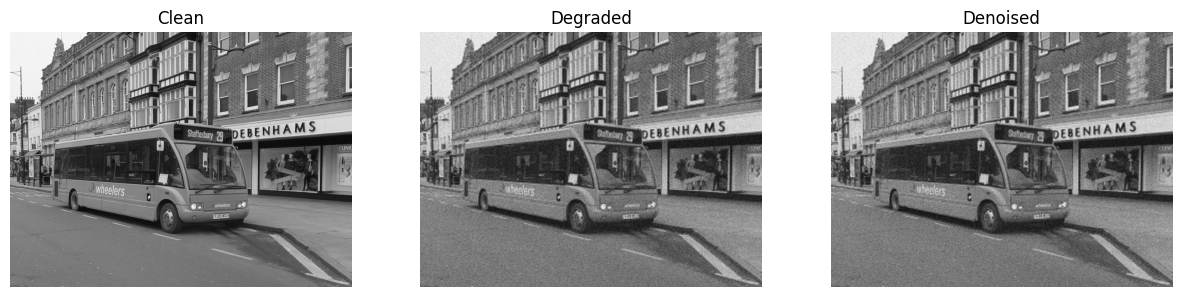

In [63]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Clean")
plt.imshow(clean, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Degraded")
plt.imshow(degraded, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Denoised")
plt.imshow(out, cmap="gray")
plt.axis("off")

plt.show()